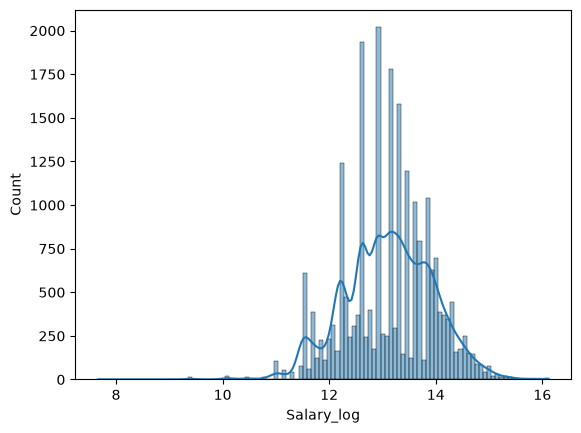

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles', 'Salary_log'],
      dtype='str')

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../../Datasets/Salary_Dataset.csv")
df.describe()
df[df["Salary"] == 90000000]
df.drop(index=18635, inplace=True)
df['Salary'].skew()
df["Salary_log"] = np.log1p(df["Salary"])
sns.histplot(df['Salary_log'], kde=True)
plt.show()
df[['Rating', 'Salary_log']].corr()
df.columns

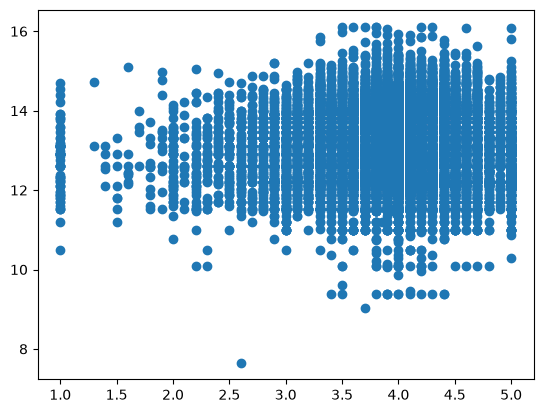

In [3]:
df.dropna(inplace=True)
plt.scatter(df["Rating"],df["Salary_log"])

In [4]:
x = df[["Rating"]]
y = df["Salary_log"]

X_train, X_test, y_train, y_test = train_test_split(x,y,train_size=0.2,random_state=32)

lr = LinearRegression()

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Rating']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.96
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [5]:
y_pred =lr.predict(X_test)

In [9]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
score

0.0005456216855155294

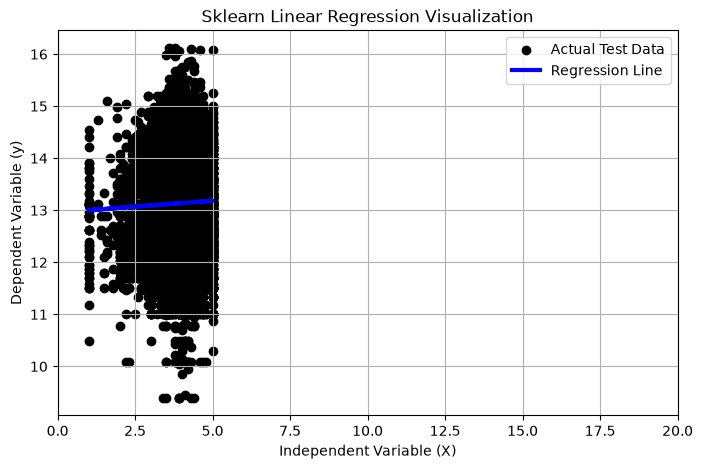

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='black', label='Actual Test Data')  # Actual data points
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Regression Line')  # Fit line
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (y)')
plt.title('Sklearn Linear Regression Visualization')
plt.legend()
plt.xlim((0,20))
plt.grid(True)
plt.show()

In [ ]:
# import pickle

# with open("LinerReg.pkl", "wb") as f:
#     pickle.dump(lr,f)


In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Load and subset only two features
df = load_diabetes(as_frame=True).frame
X = df[['bmi', 'bp']] 
y = df['target']

# Train the model
model = LinearRegression().fit(X, y)
print(f"R2 Score: {model.score(X, y):.4f}")


R2 Score: 0.3960
